In [1]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


📊 Loading Data...

⚖️  Original Class Distribution:
   Safe Days (0): 10005
   Fire Days (1): 4971
   Ratio: 1 Fire for every 2.0 Safe days


C:\Users\Sreeh\AppData\Local\Temp\ipykernel_8860\905941538.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Blues")



⚙️  Applying SMOTE (Generating Synthetic Fire Data)...

✅ New Class Distribution:
   Safe Days (0): 10005
   Fire Days (1): 10005
   Ratio: 1 to 1 (Perfectly Balanced)


C:\Users\Sreeh\AppData\Local\Temp\ipykernel_8860\905941538.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette="Greens")


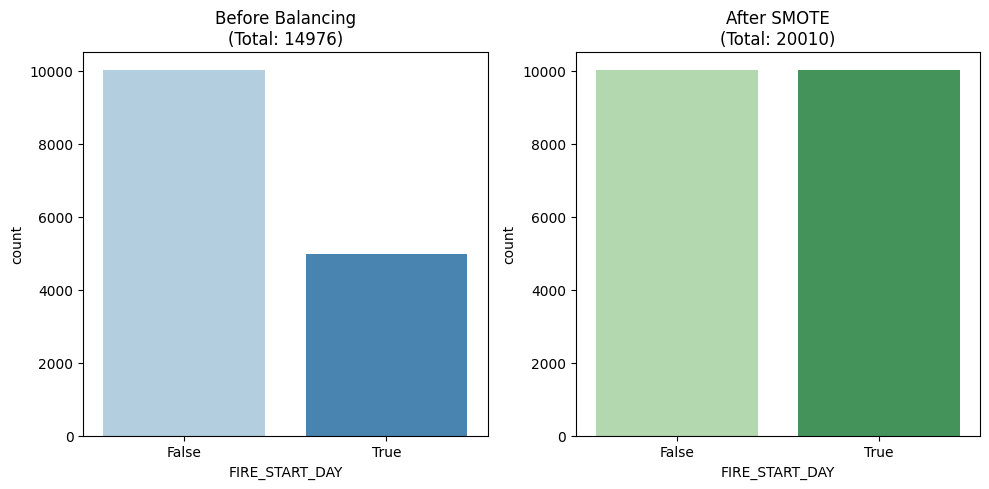


💾 Saving balanced dataset to 'california_fire_data_balanced.csv'...
✅ Done. You can now train your models on this new file.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter

# --- CONFIGURATION ---
INPUT_FILE = "california_fire_data.csv"
OUTPUT_FILE = "california_fire_data_balanced.csv"
TARGET = "FIRE_START_DAY"

# Features to use for generating synthetic samples
# (We must drop non-numeric columns like Dates for this to work)
FEATURES = [
    'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED', 
    'PRECIPITATION', 'LAGGED_PRECIPITATION', 
    'TEMP_RANGE', 'WIND_TEMP_RATIO', 'MONTH'
]

# --- 1. LOAD DATA ---
print("📊 Loading Data...")
try:
    df = pd.read_csv(INPUT_FILE)
except FileNotFoundError:
    print(f"❌ Error: {INPUT_FILE} not found.")
    exit()

# Drop rows with missing values to prevent errors
df_clean = df[FEATURES + [TARGET]].dropna()

X = df_clean[FEATURES]
y = df_clean[TARGET]

# --- 2. CHECK BALANCE BEFORE ---
print(f"\n⚖️  Original Class Distribution:")
counter = Counter(y)
print(f"   Safe Days (0): {counter[0]}")
print(f"   Fire Days (1): {counter[1]}")
print(f"   Ratio: 1 Fire for every {counter[0]/counter[1]:.1f} Safe days")

# Visual Before
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y, palette="Blues")
plt.title(f"Before Balancing\n(Total: {len(y)})")

# --- 3. APPLY SMOTE (The Magic Step) ---
print("\n⚙️  Applying SMOTE (Generating Synthetic Fire Data)...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# --- 4. CHECK BALANCE AFTER ---
print(f"\n✅ New Class Distribution:")
counter_new = Counter(y_resampled)
print(f"   Safe Days (0): {counter_new[0]}")
print(f"   Fire Days (1): {counter_new[1]}")
print(f"   Ratio: 1 to 1 (Perfectly Balanced)")

# Visual After
plt.subplot(1, 2, 2)
sns.countplot(x=y_resampled, palette="Greens")
plt.title(f"After SMOTE\n(Total: {len(y_resampled)})")
plt.tight_layout()
plt.show()

# --- 5. SAVE NEW DATASET ---
print(f"\n💾 Saving balanced dataset to '{OUTPUT_FILE}'...")
# We combine the X (features) and y (target) back into one DataFrame
df_balanced = pd.DataFrame(X_resampled, columns=FEATURES)
df_balanced[TARGET] = y_resampled

df_balanced.to_csv(OUTPUT_FILE, index=False)
print("✅ Done. You can now train your models on this new file.")